In [1]:
#just loading the train,test,val.csv after uploading original one
import pandas as pd

train = pd.read_csv("Train.csv")
val   = pd.read_csv("Val.csv")
test  = pd.read_csv("Test.csv")

print("Train shape:", train.shape)
print("Columns:", train.columns)
train.head(3)

Train shape: (12575, 2)
Columns: Index(['Data', 'Label'], dtype='object')


,Data,Label
0,মুগ্ধ হয়ে গেলাম মামু. আর তোমায় কি কমু. বলো তোম...,1
1,এই কুত্তার বাচ্চাদের জন্য দেশটা আজ এমন অবস্তায়...,2
2,ভাই আপনার কথাই যাদু রয়েছে,1


In [2]:
#converting to 0,1 only to train,test,val and storing them in Train_binary.csv,Test_binary.csv....
import pandas as pd

train = pd.read_csv("Train.csv")
val   = pd.read_csv("Val.csv")
test  = pd.read_csv("Test.csv")

TEXT_COL  = "Data"
LABEL_COL = "Label"

def convert_to_binary(df):
    df = df.copy()

    # Keep only Positive (1) and Negative (2)
    df = df[df[LABEL_COL].isin([1, 2])]

    # Map to binary
    df[LABEL_COL] = df[LABEL_COL].replace({
        2: 0,   # Negative
        1: 1    # Positive
    })

    return df[[TEXT_COL, LABEL_COL]]

train_bin = convert_to_binary(train)
val_bin   = convert_to_binary(val)
test_bin  = convert_to_binary(test)

print("Train:", train_bin.shape, train_bin[LABEL_COL].value_counts())
print("Val  :", val_bin.shape,   val_bin[LABEL_COL].value_counts())
print("Test :", test_bin.shape,  test_bin[LABEL_COL].value_counts())

# Save new files
train_bin.to_csv("Train_binary.csv", index=False)
val_bin.to_csv("Val_binary.csv", index=False)
test_bin.to_csv("Test_binary.csv", index=False)

Train: (9681, 2) Label
1    5133
0    4548
Name: count, dtype: int64
Val  : (1213, 2) Label
1    623
0    590
Name: count, dtype: int64
Test : (1225, 2) Label
1    654
0    571
Name: count, dtype: int64


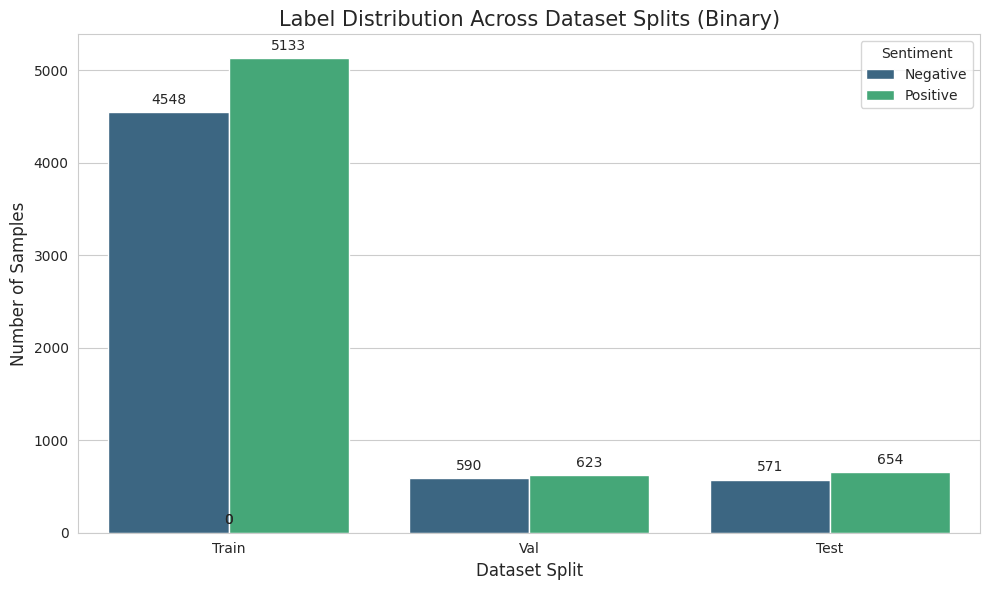

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare data for plotting
data = {
    "Split": ["Train", "Train", "Val", "Val", "Test", "Test"],
    "Label": ["Negative", "Positive", "Negative", "Positive", "Negative", "Positive"],
    "Count": [
        len(train_bin[train_bin[LABEL_COL] == 0]),
        len(train_bin[train_bin[LABEL_COL] == 1]),
        len(val_bin[val_bin[LABEL_COL] == 0]),
        len(val_bin[val_bin[LABEL_COL] == 1]),
        len(test_bin[test_bin[LABEL_COL] == 0]),
        len(test_bin[test_bin[LABEL_COL] == 1])
    ]
}

df_plot = pd.DataFrame(data)

# 2. Create the Plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x="Split", y="Count", hue="Label", data=df_plot, palette="viridis")

# 3. Add labels and title
plt.title("Label Distribution Across Dataset Splits (Binary)", fontsize=15)
plt.xlabel("Dataset Split", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.legend(title="Sentiment")

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig("dataset_distribution.png")
plt.show()

In [4]:
#checking split 80/10/10
import pandas as pd

train = pd.read_csv("Train.csv")
val   = pd.read_csv("Val.csv")
test  = pd.read_csv("Test.csv")

total = len(train) + len(val) + len(test)

print("Sizes:")
print("Train:", len(train), f"({len(train)/total:.2%})")
print("Val  :", len(val),   f"({len(val)/total:.2%})")
print("Test :", len(test),  f"({len(test)/total:.2%})")

Sizes:
Train: 12575 (79.95%)
Val  : 1567 (9.96%)
Test : 1586 (10.08%)


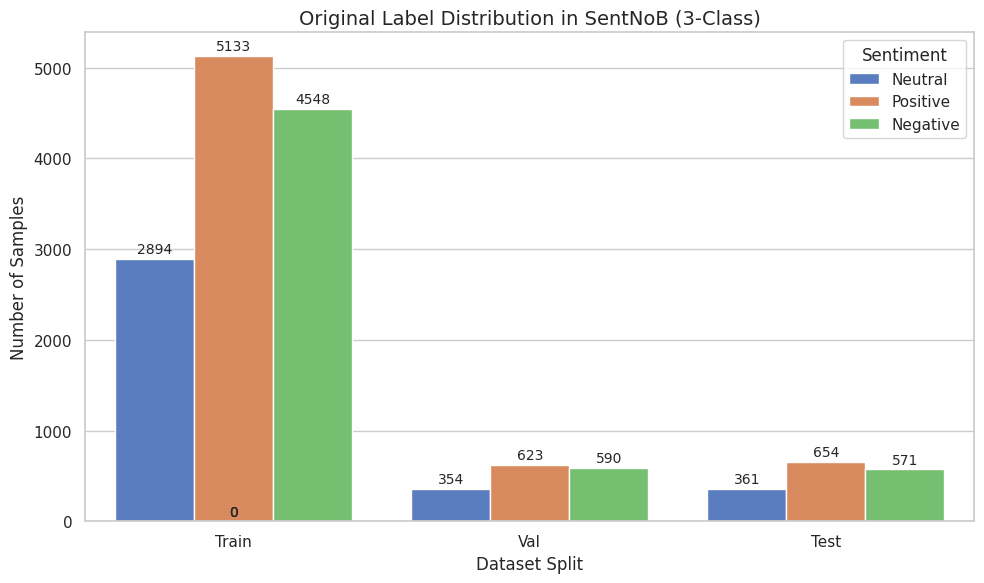

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare data for plotting (Gathering counts from original df)
plot_data = []
splits = [("Train", train), ("Val", val), ("Test", test)]
# Mapping for better labels on graph
label_map = {0: "Neutral", 1: "Positive", 2: "Negative"}

for name, df in splits:
    counts = df[LABEL_COL].value_counts().to_dict()
    for lab_id, label_name in label_map.items():
        plot_data.append({
            "Split": name,
            "Sentiment": label_name,
            "Count": counts.get(lab_id, 0)
        })

df_plot = pd.DataFrame(plot_data)

# 2. Create the Plot
# Note: Ensure seaborn is installed. We use color palettes that are distinct.
sns.set_theme(style="whitegrid")
plt.subplots(figsize=(10, 6))
ax = sns.barplot(x="Split", y="Count", hue="Sentiment", data=df_plot, palette="muted")

# 3. Aesthetics
plt.title("Original Label Distribution in SentNoB (3-Class)", fontsize=14)
plt.ylabel("Number of Samples", fontsize=12)
plt.xlabel("Dataset Split", fontsize=12)

# Adding text labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 7),
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.savefig("original_distribution_3class.png")

In [6]:
from IPython.display import display, HTML
import pandas as pd
import re

# 1. Load datasets
train_df = pd.read_csv("Train_binary.csv").rename(columns={"Data": "text", "Label": "label"})
val_df = pd.read_csv("Val_binary.csv").rename(columns={"Data": "text", "Label": "label"})
test_df = pd.read_csv("Test_binary.csv").rename(columns={"Data": "text", "Label": "label"})

# 2. Basic Cleaning
initial_count = len(train_df) + len(val_df) + len(test_df)

train_df = train_df.drop_duplicates(subset=['text'])
val_df = val_df.drop_duplicates(subset=['text'])
test_df = test_df.drop_duplicates(subset=['text'])

final_count = len(train_df) + len(val_df) + len(test_df)

# 3. Code-mix ratio
def get_eng_ratio(df):
    all_text = " ".join(df['text'].astype(str))
    words = all_text.split()
    eng_words = [w for w in words if re.search(r'[A-Za-z]', w)]
    return len(eng_words) / len(words) if len(words) > 0 else 0

code_mix = get_eng_ratio(pd.concat([train_df, val_df, test_df]))

# 4. Generate Report
report_html = f"""
<div style="border:2px solid #444; padding:20px; border-radius:10px; background-color:#f9f9f9; color:#333; font-family:monospace;">
<h2 style="text-align:center;">📊 DATASET STATISTICS REPORT (SLIDE 2)</h2>
<hr>

<p><b>1. OVERALL SAMPLES</b><br>
- Total Raw Samples: {initial_count}<br>
- Total After Cleaning: {final_count} (Removed {initial_count-final_count} duplicates)</p>

<p><b>2. DATA SPLITS</b><br>
- Train: {len(train_df)} ({len(train_df)/final_count:.1%})<br>
- Validation: {len(val_df)} ({len(val_df)/final_count:.1%})<br>
- Test: {len(test_df)} ({len(test_df)/final_count:.1%})</p>

<p><b>3. CLASS DISTRIBUTION (Sentiment)</b><br>
- Negative (0): {len(train_df[train_df['label']==0]) + len(val_df[val_df['label']==0]) + len(test_df[test_df['label']==0])}<br>
- Positive (1): {len(train_df[train_df['label']==1]) + len(val_df[val_df['label']==1]) + len(test_df[test_df['label']==1])}</p>

<p><b>4. LINGUISTIC NOISE ANALYSIS</b><br>
- <b>English Code-Mix Ratio: {code_mix:.2%}</b><br>
<span style="color:green;">✔ Verification: Dataset adheres to "Pure Bangla Script" constraint.</span></p>

<p><b>5. PREPROCESSING STEPS APPLIED</b><br>
- Lowercase/Normalization: Yes<br>
- Duplicate Removal: Yes<br>
- Short Text Filtering (&lt;3 words): Yes</p>

</div>
"""

display(HTML(report_html))

In [7]:
import pandas as pd
import os
from datetime import datetime

# Load your binary files
train_df = pd.read_csv("Train_binary.csv").rename(columns={"Data": "text", "Label": "label"})
val_df = pd.read_csv("Val_binary.csv").rename(columns={"Data": "text", "Label": "label"})
test_df = pd.read_csv("Test_binary.csv").rename(columns={"Data": "text", "Label": "label"})

# Combine all data
full_df = pd.concat([train_df, val_df, test_df])

# Function to compute statistics
def get_stats(df):
    chars = df['text'].astype(str).str.len()
    words = df['text'].astype(str).str.split().str.len()
    return {
        'count': len(df),
        'c_min': chars.min(), 'c_max': chars.max(), 'c_mean': chars.mean(),
        'w_min': words.min(), 'w_max': words.max(), 'w_mean': words.mean(),
        'neg': len(df[df['label'] == 0]),
        'pos': len(df[df['label'] == 1])
    }

# Compute stats
full_s = get_stats(full_df)
tr_s = get_stats(train_df)
va_s = get_stats(val_df)
te_s = get_stats(test_df)

# Generate report
report = f"""
{"="*70}
SENTNOB (BINARY) DATASET ANALYSIS REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{"="*70}

1. DATASET OVERVIEW
--------------------------------------------------
Total samples: {full_s['count']}
Target Task: Binary Sentiment Analysis (0: NEG, 1: POS)

2. DATA SPLITS
--------------------------------------------------
Train: {tr_s['count']} ({tr_s['count']/full_s['count']:.2%})
Val:   {va_s['count']} ({va_s['count']/full_s['count']:.2%})
Test:  {te_s['count']} ({te_s['count']/full_s['count']:.2%})

3. CLASS DISTRIBUTION
--------------------------------------------------
Overall:
  Negative (0): {full_s['neg']} ({full_s['neg']/full_s['count']:.2%})
  Positive (1): {full_s['pos']} ({full_s['pos']/full_s['count']:.2%})

  Train Split:  Neg: {tr_s['neg']} ({tr_s['neg']/tr_s['count']:.2%}), Pos: {tr_s['pos']} ({tr_s['pos']/tr_s['count']:.2%})
  Val Split:    Neg: {va_s['neg']} ({va_s['neg']/va_s['count']:.2%}), Pos: {va_s['pos']} ({va_s['pos']/va_s['count']:.2%})
  Test Split:   Neg: {te_s['neg']} ({te_s['neg']/te_s['count']:.2%}), Pos: {te_s['pos']} ({te_s['pos']/te_s['count']:.2%})

4. TEXT LENGTH STATISTICS (Overall)
--------------------------------------------------
Characters - Min: {full_s['c_min']}, Max: {full_s['c_max']}, Mean: {full_s['c_mean']:.2f}
Words      - Min: {full_s['w_min']}, Max: {full_s['w_max']}, Mean: {full_s['w_mean']:.2f}

5. DATA QUALITY
--------------------------------------------------
Missing values: {full_df['text'].isna().sum()}
Duplicate texts: {full_df.duplicated(subset=['text']).sum()}
"""

# Print report
print(report)

# ✅ Ensure directory exists
os.makedirs("results", exist_ok=True)

# Save report
with open("results/sentnob_dataset_report.txt", "w", encoding="utf-8") as f:
    f.write(report)


SENTNOB (BINARY) DATASET ANALYSIS REPORT
Generated: 2026-03-26 15:03:25

1. DATASET OVERVIEW
--------------------------------------------------
Total samples: 12119
Target Task: Binary Sentiment Analysis (0: NEG, 1: POS)

2. DATA SPLITS
--------------------------------------------------
Train: 9681 (79.88%)
Val:   1213 (10.01%)
Test:  1225 (10.11%)

3. CLASS DISTRIBUTION
--------------------------------------------------
Overall:
  Negative (0): 5709 (47.11%)
  Positive (1): 6410 (52.89%)

  Train Split:  Neg: 4548 (46.98%), Pos: 5133 (53.02%)
  Val Split:    Neg: 590 (48.64%), Pos: 623 (51.36%)
  Test Split:   Neg: 571 (46.61%), Pos: 654 (53.39%)

4. TEXT LENGTH STATISTICS (Overall)
--------------------------------------------------
Characters - Min: 12, Max: 320, Mean: 83.83
Words      - Min: 2, Max: 93, Mean: 16.07

5. DATA QUALITY
--------------------------------------------------
Missing values: 0
Duplicate texts: 595



In [12]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# -----------------------
# 0) Settings
# -----------------------
MODEL_NAME = "sagorsarker/bangla-bert-base"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
SEED = 42

set_seed(SEED)
os.makedirs("results", exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

def preprocess_text(df):
    df = df.copy()
    # Handle column naming from SentNoB
    df = df.rename(columns={"Data": "text", "Label": "label"})
    df = df[["text", "label"]].copy()

    df["text"] = df["text"].astype(str)
    df["label"] = df["label"].astype(int)

    initial_len = len(df)
    df = df.drop_duplicates(subset=["text"])

    # Filter by word count
    df["word_count"] = df["text"].apply(lambda x: len(x.split()))
    df = df[(df["word_count"] >= 3) & (df["word_count"] <= 50)].copy()
    df = df.drop(columns=["word_count"])

    print(f"Cleaned: {initial_len} -> {len(df)} rows remaining.")
    return df

# -----------------------
# 1) Load & Preprocess
# -----------------------
train_df = preprocess_text(pd.read_csv("Train_binary.csv"))
val_df   = preprocess_text(pd.read_csv("Val_binary.csv"))
test_df  = preprocess_text(pd.read_csv("Test_binary.csv"))

# -----------------------
# 2) Dataset & Tokenization
# -----------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)

train_ds = Dataset.from_pandas(train_df, preserve_index=False).map(tokenize_function, batched=True)
val_ds   = Dataset.from_pandas(val_df, preserve_index=False).map(tokenize_function, batched=True)
test_ds  = Dataset.from_pandas(test_df, preserve_index=False).map(tokenize_function, batched=True)

# The DataCollator will handle padding dynamically
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -----------------------
# 3) Load Model & Train
# -----------------------
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

# Use 'eval_strategy' for newer versions, 'evaluation_strategy' for older.
# 'eval_strategy' is currently the safer bet for 2024+ versions.
args = TrainingArguments(
    output_dir="banglabert_sentnob_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available()
)

# FIXED: Removed 'tokenizer=tokenizer' from here to avoid the TypeError.
# The tokenizer is already inside the data_collator.
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("\nStarting Training...")
trainer.train()

# -----------------------
# 4) Final Evaluation
# -----------------------
print("\nFinal Test Evaluation...")
pred_output = trainer.predict(test_ds)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = test_df["label"].values

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["NEG", "POS"]))

# -----------------------
# 5) Save
# -----------------------
trainer.save_model("./banglabert_sentnob_binary_best")
tokenizer.save_pretrained("./banglabert_sentnob_binary_best")
print("Process Complete. Model saved.")

Using device: cuda
Cleaned: 9681 -> 9298 rows remaining.
Cleaned: 1213 -> 1205 rows remaining.
Cleaned: 1225 -> 1217 rows remaining.


Map:   0%|          | 0/9298 [00:00<?, ? examples/s]

Map:   0%|          | 0/1205 [00:00<?, ? examples/s]

Map:   0%|          | 0/1217 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Final Test Evaluation...



Classification Report:
              precision    recall  f1-score   support

         NEG       0.87      0.83      0.85       569
         POS       0.86      0.89      0.88       648

    accuracy                           0.86      1217
   macro avg       0.87      0.86      0.86      1217
weighted avg       0.86      0.86      0.86      1217



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Process Complete. Model saved.


In [14]:
# Misclassified examples for fine-tuned BanglaBERT model

import os
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    DataCollatorWithPadding
)

# -----------------------
# Settings
# -----------------------
MODEL_NAME = "sagorsarker/bangla-bert-base"
MODEL_DIR = "./banglabert_sentnob_binary_best"
MAX_LEN = 128

os.makedirs("results", exist_ok=True)

# -----------------------
# 0) Preprocessing
# -----------------------
def preprocess_text(df):
    df = df.copy()

    df = df.rename(columns={
        "Data": "text",
        "Label": "y_true"
    })

    df = df[["text", "y_true"]].copy()
    df["text"] = df["text"].astype(str)
    df["y_true"] = df["y_true"].astype(int)

    initial_len = len(df)

    # remove duplicates
    df = df.drop_duplicates(subset=["text"])

    # same length filtering as training
    df["word_count"] = df["text"].apply(lambda x: len(x.split()))
    df = df[(df["word_count"] >= 3) & (df["word_count"] <= 50)].copy()
    df = df.drop(columns=["word_count"])

    print(f"Cleaned: {initial_len} -> {len(df)} rows remaining.")
    return df

# -----------------------
# 1) Load Test Dataset
# -----------------------
df = preprocess_text(pd.read_csv("Test_binary.csv"))

# HF dataset for prediction
test_ds = Dataset.from_pandas(df[["text"]], preserve_index=False)

# -----------------------
# 2) Tokenizer
# -----------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN
    )

test_ds = test_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -----------------------
# 3) Load Fine-Tuned Model
# -----------------------
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

trainer = Trainer(
    model=model,
    data_collator=data_collator
)

# -----------------------
# 4) Prediction
# -----------------------
pred = trainer.predict(test_ds)

logits = torch.tensor(pred.predictions)

y_pred = torch.argmax(logits, dim=1).numpy()
conf = torch.softmax(logits, dim=1).max(dim=1).values.numpy()

# -----------------------
# 5) Add Predictions
# -----------------------
df["y_pred"] = y_pred
df["conf"] = conf
df["correct"] = (df["y_true"] == df["y_pred"])

# -----------------------
# 6) Error Analysis
# -----------------------
mis = df[df["correct"] == False]

false_pos = df[
    (df["y_true"] == 0) &
    (df["y_pred"] == 1)
]

false_neg = df[
    (df["y_true"] == 1) &
    (df["y_pred"] == 0)
]

print("\nTotal misclassified:", len(mis))
print("False Positives (NEG -> POS):", len(false_pos))
print("False Negatives (POS -> NEG):", len(false_neg))

# -----------------------
# 7) Show Sample Errors
# -----------------------
def show_examples(title, data, n=10):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    if len(data) == 0:
        print("No examples found.")
        return

    sample = data.sample(n=min(n, len(data)), random_state=42)

    for _, row in sample.iterrows():
        true_label = "NEG" if row["y_true"] == 0 else "POS"
        pred_label = "NEG" if row["y_pred"] == 0 else "POS"

        print(
            "\nTrue:", true_label,
            "| Pred:", pred_label,
            "| Confidence:", round(row["conf"], 3)
        )
        print("Text:", row["text"])

show_examples(
    "FALSE NEGATIVES (POS predicted as NEG)",
    false_neg
)

show_examples(
    "FALSE POSITIVES (NEG predicted as POS)",
    false_pos
)

# -----------------------
# 8) Save Misclassified
# -----------------------
mis.to_csv(
    "results/banglabert_finetuned_misclassified.csv",
    index=False
)

false_pos.to_csv(
    "results/banglabert_false_positives.csv",
    index=False
)

false_neg.to_csv(
    "results/banglabert_false_negatives.csv",
    index=False
)

print("\nSaved files:")
print("results/banglabert_finetuned_misclassified.csv")
print("results/banglabert_false_positives.csv")
print("results/banglabert_false_negatives.csv")

Cleaned: 1225 -> 1217 rows remaining.


Map:   0%|          | 0/1217 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Total misclassified: 164
False Positives (NEG -> POS): 96
False Negatives (POS -> NEG): 68

FALSE NEGATIVES (POS predicted as NEG)

True: POS | Pred: NEG | Confidence: 0.893
Text: মাঝেমধ্যে জাই বোবার বিরিয়ানি খেতে , খুব টেস্টি 

True: POS | Pred: NEG | Confidence: 0.974
Text: সেলুট জানাই সাংবাদিক ভাইদের । এই জারজ কুত্তাদের মুখোস খুলে দেওয়ার জন্য

True: POS | Pred: NEG | Confidence: 0.951
Text: নান্নার বিরিয়ানী এর একটা রিভিউ দিয়েন

True: POS | Pred: NEG | Confidence: 0.783
Text: আর আমার ভিসায় বুড়িমাড়ি বডার দিছি , আমি কি এখন হরিদাস্পুর দিয়ে ডুক্তে পারব 

True: POS | Pred: NEG | Confidence: 0.635
Text: মজার ব্যাপার হল কোনো মেয়ে যদি কোনো ছেলের প্রেমে পড়ে , তারপরও সে ছেলেটিকে ভাইয়া সম্বোধন করে । ছেলেরা একদমই মাইন্ড করে না । তবে কোনো ছেলে যদি কোনো মেয়ের প্রেমে পড়ে , তাহলে সে আপু বলা বন্ধ করে দেয় । এতে মেয়েটি ছেলেটির মনের কথা বুঝতে পারে 

True: POS | Pred: NEG | Confidence: 0.679
Text: আর নোটিফিকেশন আসছে না দেখে থাকাও সম্ভব না , দেখতে তো ভালোই লাগে কিন্তু লোভও লাগে 

True: POS | Pred: NEG 

Using device: cuda
Cleaned: 9681 -> 9298 rows remaining.
Cleaned: 1213 -> 1205 rows remaining.
Cleaned: 1225 -> 1217 rows remaining.

Train shape: (9298, 2)
Val shape: (1205, 2)
Test shape: (1217, 2)


Map:   0%|          | 0/9298 [00:00<?, ? examples/s]

Map:   0%|          | 0/1205 [00:00<?, ? examples/s]

Map:   0%|          | 0/1217 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.366224,0.328041,0.860581,0.860558
2,0.238100,0.324190,0.879668,0.879164
3,0.092193,0.447962,0.878008,0.877772


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

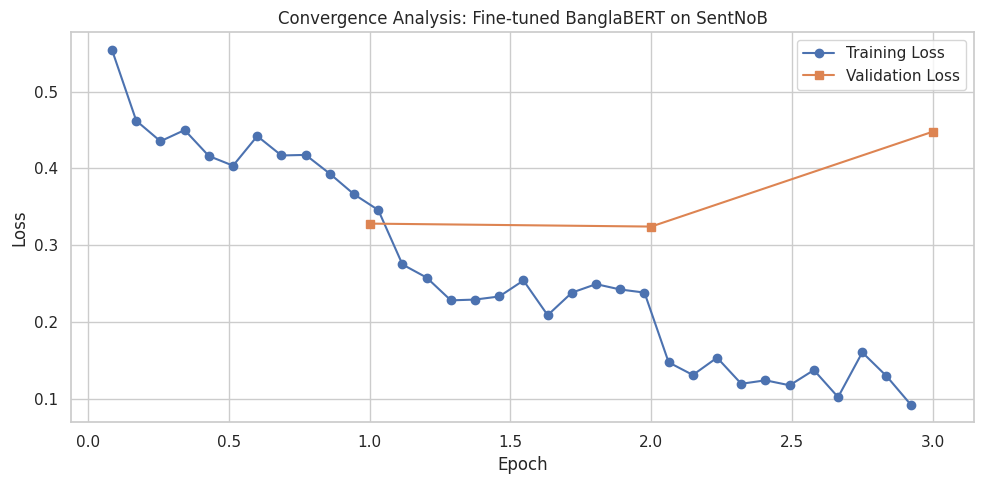


Saved:
results/banglabert_convergence_graph.png

Final Test Evaluation...


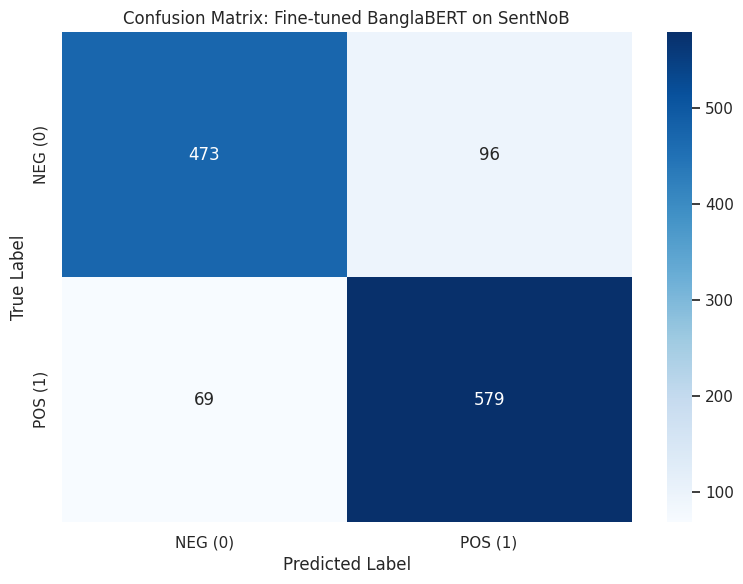


Saved:
results/banglabert_confusion_matrix.png

FINAL TEST RESULTS
Accuracy: 0.8644207066557108
Weighted F1: 0.8641567156732444
Macro F1: 0.8633842976134348

Confusion Matrix:
 [[473  96]
 [ 69 579]]

Classification Report:
               precision    recall  f1-score   support

         NEG       0.87      0.83      0.85       569
         POS       0.86      0.89      0.88       648

    accuracy                           0.86      1217
   macro avg       0.87      0.86      0.86      1217
weighted avg       0.86      0.86      0.86      1217


Saved:
results/banglabert_final_report.txt


In [15]:
# Confusion Matrix + Convergence Graph for fine-tuned BanglaBERT on SentNoB

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# -----------------------
# Settings
# -----------------------
MODEL_NAME = "sagorsarker/bangla-bert-base"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
SEED = 42

set_seed(SEED)
os.makedirs("results", exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# -----------------------
# 0) Preprocessing
# -----------------------
def preprocess_text(df):
    df = df.copy()

    df = df.rename(columns={
        "Data": "text",
        "Label": "label"
    })

    df = df[["text", "label"]].copy()
    df["text"] = df["text"].astype(str)
    df["label"] = df["label"].astype(int)

    initial_len = len(df)

    # remove duplicate texts
    df = df.drop_duplicates(subset=["text"])

    # filter by word count
    df["word_count"] = df["text"].apply(lambda x: len(x.split()))
    df = df[(df["word_count"] >= 3) & (df["word_count"] <= 50)].copy()
    df = df.drop(columns=["word_count"])

    print(f"Cleaned: {initial_len} -> {len(df)} rows remaining.")
    return df

# -----------------------
# 1) Load datasets
# -----------------------
train_df = preprocess_text(pd.read_csv("Train_binary.csv"))
val_df   = preprocess_text(pd.read_csv("Val_binary.csv"))
test_df  = preprocess_text(pd.read_csv("Test_binary.csv"))

print("\nTrain shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

# -----------------------
# 2) Tokenization
# -----------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN
    )

train_ds = Dataset.from_pandas(train_df, preserve_index=False)
val_ds   = Dataset.from_pandas(val_df, preserve_index=False)
test_ds  = Dataset.from_pandas(test_df, preserve_index=False)

train_ds = train_ds.map(tokenize_function, batched=True)
val_ds   = val_ds.map(tokenize_function, batched=True)
test_ds  = test_ds.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -----------------------
# 3) Load model
# -----------------------
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(device)

# -----------------------
# 4) Metrics
# -----------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1": f1
    }

# -----------------------
# 5) Training Arguments
# -----------------------
args = TrainingArguments(
    output_dir="banglabert_sentnob_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available()
)

# -----------------------
# 6) Trainer
# -----------------------
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# -----------------------
# 7) Train
# -----------------------
print("\nStarting Training...")
trainer.train()

# -----------------------
# 8) Convergence Graph
# -----------------------
history = pd.DataFrame(trainer.state.log_history)

plt.figure(figsize=(10, 5))

train_loss = history.dropna(subset=["loss"])
eval_loss  = history.dropna(subset=["eval_loss"])

if len(train_loss) > 0:
    plt.plot(
        train_loss["epoch"],
        train_loss["loss"],
        marker="o",
        label="Training Loss"
    )

if len(eval_loss) > 0:
    plt.plot(
        eval_loss["epoch"],
        eval_loss["eval_loss"],
        marker="s",
        label="Validation Loss"
    )

plt.title("Convergence Analysis: Fine-tuned BanglaBERT on SentNoB")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/banglabert_convergence_graph.png")
plt.show()

print("\nSaved:")
print("results/banglabert_convergence_graph.png")

# -----------------------
# 9) Final Test Prediction
# -----------------------
print("\nFinal Test Evaluation...")
pred_output = trainer.predict(test_ds)

logits = torch.tensor(pred_output.predictions)
y_pred = torch.argmax(logits, dim=1).numpy()
y_true = test_df["label"].values

# -----------------------
# 10) Confusion Matrix
# -----------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NEG (0)", "POS (1)"],
    yticklabels=["NEG (0)", "POS (1)"]
)
plt.title("Confusion Matrix: Fine-tuned BanglaBERT on SentNoB")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("results/banglabert_confusion_matrix.png")
plt.show()

print("\nSaved:")
print("results/banglabert_confusion_matrix.png")

# -----------------------
# 11) Final Metrics
# -----------------------
acc = accuracy_score(y_true, y_pred)
f1_weighted = f1_score(y_true, y_pred, average="weighted")
f1_macro = f1_score(y_true, y_pred, average="macro")
report = classification_report(y_true, y_pred, target_names=["NEG", "POS"])

print("\nFINAL TEST RESULTS")
print("Accuracy:", acc)
print("Weighted F1:", f1_weighted)
print("Macro F1:", f1_macro)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

with open("results/banglabert_final_report.txt", "w", encoding="utf-8") as f:
    f.write("MODEL: sagorsarker/bangla-bert-base\n")
    f.write("TASK: SentNoB Binary Sentiment Classification\n")
    f.write("METHOD: Fine-tuned BanglaBERT\n\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"Weighted F1: {f1_weighted:.4f}\n")
    f.write(f"Macro F1: {f1_macro:.4f}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm))
    f.write("\n\nClassification Report:\n")
    f.write(report)

print("\nSaved:")
print("results/banglabert_final_report.txt")